In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src.lstm_encoder import HybridCNNBiLSTMEncoder
from src.fdi_classifier import TransferFDIClassifier

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Executing Phase 17 Limited-Label Benchmark on: {device}")

# 1. Load Dataset B (Phase 13 artifact)
data_path = Path('../data/processed_downstream/fdi_feeder_windows.npz')
data = np.load(data_path)

X_train, y_train = data['X_train'], data['y_train']
X_val, y_val     = data['X_val'],   data['y_val']
X_test, y_test   = data['X_test'],  data['y_test']

print(f"Full Data Partitions -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Pretrained Backbone Path
pretrained_checkpoint = Path('../saved_models/ssl_cnn_bilstm.pth')
assert pretrained_checkpoint.exists(), f"Pretrained backbone missing at: {pretrained_checkpoint}"

# Common Validation and Test Loaders
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val).float().unsqueeze(1)),
    batch_size=64, shuffle=False
)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test).float().unsqueeze(1)),
    batch_size=64, shuffle=False
)

Executing Phase 17 Limited-Label Benchmark on: cuda
Full Data Partitions -> Train: (5011, 30, 12), Val: (1051, 30, 12), Test: (1052, 30, 12)


In [2]:
class ScratchFDIModel(nn.Module):
    """Native 12-channel model trained purely from scratch."""
    def __init__(self, in_channels=12, cnn_hidden_dims=(64, 128), lstm_hidden_dim=128, mlp_hidden_dim=64):
        super().__init__()
        self.encoder = HybridCNNBiLSTMEncoder(
            in_channels=in_channels,
            cnn_hidden_dims=cnn_hidden_dims,
            lstm_hidden_dim=lstm_hidden_dim,
            lstm_layers=2,
            pool_strategy="mean"
        )
        self.mlp_head = nn.Sequential(
            nn.Linear(self.encoder.out_dim, mlp_hidden_dim),
            nn.BatchNorm1d(mlp_hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(mlp_hidden_dim, 1)
        )

    def forward(self, x):
        h = self.encoder(x, return_sequence=False)
        return self.mlp_head(h)


def evaluate_test_set(model, loader):
    """Evaluates hold-out test set and returns primary metrics."""
    model.eval()
    probs, preds, targets = [], [], []
    with torch.no_grad():
        for x_b, y_b in loader:
            x_b = x_b.to(device)
            logits = model(x_b)
            p = torch.sigmoid(logits).cpu().numpy().flatten()
            pr = (p >= 0.5).astype(int)
            probs.extend(p)
            preds.extend(pr)
            targets.extend(y_b.numpy().flatten())
            
    probs = np.array(probs)
    preds = np.array(preds)
    targets = np.array(targets)
    
    return {
        'accuracy':  accuracy_score(targets, preds),
        'precision': precision_score(targets, preds, zero_division=0),
        'recall':    recall_score(targets, preds, zero_division=0),
        'f1':        f1_score(targets, preds, zero_division=0),
        'roc_auc':   roc_auc_score(targets, probs)
    }

In [3]:
FRACTIONS = [0.10, 0.25, 0.50, 0.75, 1.00]
EPOCHS = 20

results_records = []

print("=" * 80)
print("STARTING PHASE 17 LIMITED-LABEL EXPERIMENT (SCRATCH vs. SSL FINE-TUNED)")
print("=" * 80)

for frac in FRACTIONS:
    print(f"\n>>> Running Experiments for Label Fraction: {int(frac*100)}% <<<")
    
    # 1. Stratified Subsampling of Training Data
    if frac < 1.00:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=frac, random_state=42)
        train_idx, _ = next(sss.split(X_train, y_train))
        X_sub, y_sub = X_train[train_idx], y_train[train_idx]
    else:
        X_sub, y_sub = X_train, y_train
        
    print(f"Subsampled Training Budget: {len(X_sub)} windows | Attacks: {y_sub.sum()} ({y_sub.mean()*100:.2f}%)")
    
    # DataLoaders & Class Weight
    sub_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_sub), torch.from_numpy(y_sub).float().unsqueeze(1)),
        batch_size=32 if frac <= 0.25 else 64,
        shuffle=True, pin_memory=True
    )
    pos_weight = torch.tensor([(y_sub == 0).sum() / (y_sub == 1).sum()], device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    # -------------------------------------------------------------------------
    # Train Model A: From Scratch
    # -------------------------------------------------------------------------
    model_scratch = ScratchFDIModel().to(device)
    opt_scratch = torch.optim.AdamW(model_scratch.parameters(), lr=1e-3, weight_decay=1e-4)
    sched_scratch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_scratch, mode='min', factor=0.5, patience=2)
    
    best_scratch_val_f1 = -1.0
    best_scratch_state = None
    
    for ep in range(1, EPOCHS + 1):
        model_scratch.train()
        for x_b, y_b in sub_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            opt_scratch.zero_grad()
            l = criterion(model_scratch(x_b), y_b)
            l.backward()
            torch.nn.utils.clip_grad_norm_(model_scratch.parameters(), 5.0)
            opt_scratch.step()
            
        # Val check
        model_scratch.eval()
        v_preds, v_targets, v_loss = [], [], 0.0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                lg = model_scratch(x_b)
                v_loss += criterion(lg, y_b).item() * len(x_b)
                v_preds.extend((torch.sigmoid(lg) >= 0.5).int().cpu().numpy().flatten())
                v_targets.extend(y_b.cpu().numpy().flatten())
        v_loss /= len(val_loader.dataset)
        v_f1 = f1_score(v_targets, v_preds, zero_division=0)
        sched_scratch.step(v_loss)
        
        if v_f1 > best_scratch_val_f1:
            best_scratch_val_f1 = v_f1
            best_scratch_state = model_scratch.state_dict().copy()
            
    model_scratch.load_state_dict(best_scratch_state)
    metrics_scratch = evaluate_test_set(model_scratch, test_loader)
    
    # -------------------------------------------------------------------------
    # Train Model B: Pretrained SSL Backbone (Fine-Tuning)
    # -------------------------------------------------------------------------
    model_ssl = TransferFDIClassifier(
        in_channels=12,
        pretrained_channels=25,
        cnn_hidden_dims=(64, 128),
        lstm_hidden_dim=128,
        lstm_layers=2,
        mlp_hidden_dim=64,
        dropout=0.3,
        freeze_backbone=False
    ).to(device)
    model_ssl.load_pretrained_backbone(pretrained_checkpoint, device)
    
    opt_ssl = torch.optim.AdamW([
        {'params': model_ssl.channel_projector.parameters(), 'lr': 1e-3, 'weight_decay': 1e-4},
        {'params': model_ssl.encoder.parameters(),           'lr': 5e-5, 'weight_decay': 1e-4},
        {'params': model_ssl.mlp_head.parameters(),          'lr': 1e-3, 'weight_decay': 1e-4}
    ])
    sched_ssl = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_ssl, mode='min', factor=0.5, patience=2)
    
    best_ssl_val_f1 = -1.0
    best_ssl_state = None
    
    for ep in range(1, EPOCHS + 1):
        model_ssl.train()
        for x_b, y_b in sub_loader:
            x_b, y_b = x_b.to(device), y_b.to(device)
            opt_ssl.zero_grad()
            l = criterion(model_ssl(x_b), y_b)
            l.backward()
            torch.nn.utils.clip_grad_norm_(model_ssl.parameters(), 5.0)
            opt_ssl.step()
            
        # Val check
        model_ssl.eval()
        v_preds, v_targets, v_loss = [], [], 0.0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(device), y_b.to(device)
                lg = model_ssl(x_b)
                v_loss += criterion(lg, y_b).item() * len(x_b)
                v_preds.extend((torch.sigmoid(lg) >= 0.5).int().cpu().numpy().flatten())
                v_targets.extend(y_b.cpu().numpy().flatten())
        v_loss /= len(val_loader.dataset)
        v_f1 = f1_score(v_targets, v_preds, zero_division=0)
        sched_ssl.step(v_loss)
        
        if v_f1 > best_ssl_val_f1:
            best_ssl_val_f1 = v_f1
            best_ssl_state = model_ssl.state_dict().copy()
            
    model_ssl.load_state_dict(best_ssl_state)
    metrics_ssl = evaluate_test_set(model_ssl, test_loader)
    
    print(f"Fraction {int(frac*100)}% Test Results:")
    print(f"  • Scratch -> F1: {metrics_scratch['f1']*100:.2f}% | Precision: {metrics_scratch['precision']*100:.2f}% | Recall: {metrics_scratch['recall']*100:.2f}% | AUC: {metrics_scratch['roc_auc']*100:.2f}%")
    print(f"  • SSL     -> F1: {metrics_ssl['f1']*100:.2f}% | Precision: {metrics_ssl['precision']*100:.2f}% | Recall: {metrics_ssl['recall']*100:.2f}% | AUC: {metrics_ssl['roc_auc']*100:.2f}%")
    
    # Store records
    results_records.append({
        'fraction': f"{int(frac*100)}%",
        'train_samples': len(X_sub),
        'scratch_f1': metrics_scratch['f1'] * 100,
        'ssl_f1': metrics_ssl['f1'] * 100,
        'scratch_recall': metrics_scratch['recall'] * 100,
        'ssl_recall': metrics_ssl['recall'] * 100,
        'scratch_precision': metrics_scratch['precision'] * 100,
        'ssl_precision': metrics_ssl['precision'] * 100,
        'scratch_auc': metrics_scratch['roc_auc'] * 100,
        'ssl_auc': metrics_ssl['roc_auc'] * 100,
    })

# Convert to DataFrame
df_limited = pd.DataFrame(results_records)
results_dir = Path('../results')
results_dir.mkdir(parents=True, exist_ok=True)
df_limited.to_csv(results_dir / 'phase17_limited_label_results.csv', index=False)

print("\n" + "=" * 80)
print("FINAL PHASE 17 LIMITED-LABEL SUMMARY TABLE")
print("=" * 80)
print(df_limited[['fraction', 'train_samples', 'scratch_f1', 'ssl_f1', 'scratch_auc', 'ssl_auc']].to_string(index=False))

STARTING PHASE 17 LIMITED-LABEL EXPERIMENT (SCRATCH vs. SSL FINE-TUNED)

>>> Running Experiments for Label Fraction: 10% <<<
Subsampled Training Budget: 501 windows | Attacks: 158 (31.54%)
[SUCCESS] Loaded Pretrained Encoder Backbone from: ..\saved_models\ssl_cnn_bilstm.pth
Fraction 10% Test Results:
  • Scratch -> F1: 7.38% | Precision: 6.47% | Recall: 8.57% | AUC: 45.19%
  • SSL     -> F1: 22.49% | Precision: 19.19% | Recall: 27.14% | AUC: 46.28%

>>> Running Experiments for Label Fraction: 25% <<<
Subsampled Training Budget: 1252 windows | Attacks: 395 (31.55%)
[SUCCESS] Loaded Pretrained Encoder Backbone from: ..\saved_models\ssl_cnn_bilstm.pth
Fraction 25% Test Results:
  • Scratch -> F1: 31.41% | Precision: 20.13% | Recall: 71.43% | AUC: 40.36%
  • SSL     -> F1: 19.01% | Precision: 13.71% | Recall: 30.95% | AUC: 44.63%

>>> Running Experiments for Label Fraction: 50% <<<
Subsampled Training Budget: 2505 windows | Attacks: 790 (31.54%)
[SUCCESS] Loaded Pretrained Encoder Backbone

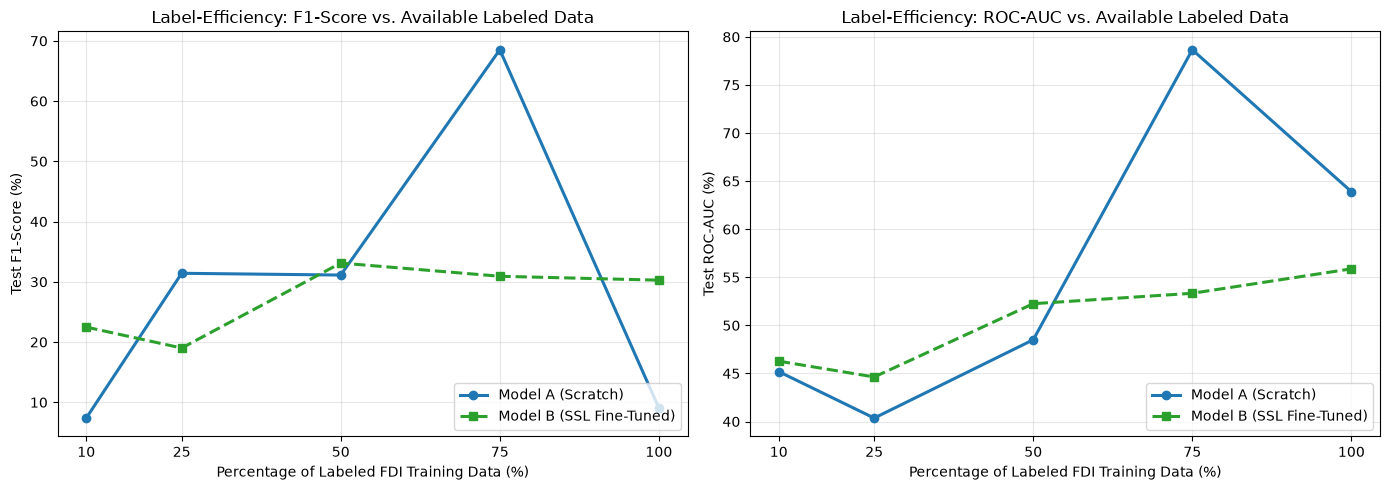

In [4]:
fig_dir = Path('../results/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fractions_numeric = [10, 25, 50, 75, 100]

# 1. F1-Score vs Label Availability
axes[0].plot(fractions_numeric, df_limited['scratch_f1'], marker='o', lw=2.2, color='#1f77b4', label='Model A (Scratch)')
axes[0].plot(fractions_numeric, df_limited['ssl_f1'], marker='s', lw=2.2, color='#2ca02c', linestyle='--', label='Model B (SSL Fine-Tuned)')
axes[0].set_title('Label-Efficiency: F1-Score vs. Available Labeled Data')
axes[0].set_xlabel('Percentage of Labeled FDI Training Data (%)')
axes[0].set_ylabel('Test F1-Score (%)')
axes[0].set_xticks(fractions_numeric)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# 2. ROC-AUC vs Label Availability
axes[1].plot(fractions_numeric, df_limited['scratch_auc'], marker='o', lw=2.2, color='#1f77b4', label='Model A (Scratch)')
axes[1].plot(fractions_numeric, df_limited['ssl_auc'], marker='s', lw=2.2, color='#2ca02c', linestyle='--', label='Model B (SSL Fine-Tuned)')
axes[1].set_title('Label-Efficiency: ROC-AUC vs. Available Labeled Data')
axes[1].set_xlabel('Percentage of Labeled FDI Training Data (%)')
axes[1].set_ylabel('Test ROC-AUC (%)')
axes[1].set_xticks(fractions_numeric)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(fig_dir / 'phase17_label_efficiency_curves.png', dpi=300)
plt.show()